# UrbanStream — KMeans Zone Clustering: Evaluation Report

This notebook trains and evaluates the offline KMeans model used to classify NYC zones into four hazard clusters.
It produces the elbow curve, silhouette scores, centroid analysis, and a final cluster assignment map.

**Pipeline position:** runs once on historical data → labels pushed to Redis → consumed by streaming recommender.

| Component | Detail |
|---|---|
| Algorithm | KMeans (sklearn), k=2..6 evaluated |
| Features | 7: avg_speed, std_speed, pct_slow, avg_pm25, std_pm25, avg_aqi_proxy, density |
| Scaling | StandardScaler (zero mean, unit variance) |
| Selection | Silhouette score; k=4 preferred for interpretability |
| Output | `cluster_offline:{zone}` keys in Redis, model saved to `ml/models/` |

In [16]:
!pip3 install pandas


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [17]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import joblib
import json

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.family':      'sans-serif',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

CLUSTER_COLORS = {
    'Permanently Hazardous': '#EF4444',
    'Peak Hour Hazardous':   '#F59E0B',
    'Weather Sensitive':     '#8B5CF6',
    'Safe Corridor':         '#10B981',
}

print('Libraries loaded. Ready.')

Libraries loaded. Ready.


In [18]:
import sys, os
sys.path.insert(0, os.path.join(BASE_DIR, 'ml'))

from clustering import (
    load_traffic, load_pollution, build_zone_features,
    assign_zone, ALL_ZONES, ZONE_COORDS, BOROUGH_MAP, CLUSTER_NAMES
)

traffic_raw   = load_traffic()
pollution_raw = load_pollution()

2026-04-14 11:08:56,237 [CLUSTERING] INFO Loading traffic data from /Users/sushantakparasharjha/Projects/urbanstream/data/nyc_traffic.csv
2026-04-14 11:08:56,308 [CLUSTERING] INFO Traffic: 0 segments across 0 boroughs
2026-04-14 11:08:56,308 [CLUSTERING] INFO Loading pollution data from /Users/sushantakparasharjha/Projects/urbanstream/data/openaq_nyc.csv
2026-04-14 11:08:56,332 [CLUSTERING] INFO Pollution: 26880 PM2.5 readings from 10 stations


## 1. Load & Inspect Raw Data

In [19]:
BASE_DIR = os.path.abspath(os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'ml' else os.getcwd())
DATA_DIR      = os.path.join(BASE_DIR, 'data')
MODEL_DIR     = os.path.join(BASE_DIR, 'ml', 'models')
TRAFFIC_CSV   = os.path.join(DATA_DIR, 'nyc_traffic.csv')
POLLUTION_CSV = os.path.join(DATA_DIR, 'openaq_nyc.csv')

traffic_df   = pd.read_csv(TRAFFIC_CSV)
pollution_df = pd.read_csv(POLLUTION_CSV)

traffic_df.columns   = [c.strip().upper() for c in traffic_df.columns]
pollution_df_pm25    = pollution_df[pollution_df['parameter'] == 'pm25'].copy()

print(f'Traffic rows   : {len(traffic_df):,}  |  columns: {list(traffic_df.columns[:6])}')
print(f'Pollution rows : {len(pollution_df_pm25):,}  |  stations: {pollution_df_pm25["location"].nunique()}')
print()
print('Traffic speed stats (mph):')
print(traffic_df['SPEED'].describe().round(2).to_string())
print()
print('PM2.5 stats (µg/m³):')
print(pollution_df_pm25['value'].describe().round(2).to_string())

Traffic rows   : 50,000  |  columns: ['SPEED', 'LINK_ID', 'DATA_AS_OF', 'BOROUGH', 'LINK_POINTS', 'TRAVEL_TIME']
Pollution rows : 26,880  |  stations: 10

Traffic speed stats (mph):
count    50000.00
mean        28.39
std         21.66
min          0.00
25%          3.72
50%         31.68
75%         48.46
max        100.04

PM2.5 stats (µg/m³):
count    26880.00
mean        11.14
std          3.81
min          0.10
25%          8.46
50%         10.97
75%         13.54
max         26.90


## 2. Feature Engineering

We aggregate raw rows to one feature vector per zone (30 zones total across 5 NYC boroughs).

| Feature | Source | Rationale |
|---|---|---|
| `avg_speed` | Traffic CSV | Core congestion indicator |
| `std_speed` | Traffic CSV | Speed variance — captures peak-hour swings |
| `pct_slow` | Traffic CSV | Fraction of readings below 20 mph |
| `avg_pm25` | OpenAQ CSV | Core air quality indicator |
| `std_pm25` | OpenAQ CSV | Pollution variance — weather-sensitive zones |
| `avg_aqi_proxy` | Derived (pm25 × 4) | EPA linear AQI approximation |
| `density` | Borough lookup | Population density proxy (MN=1.0 … SI=0.3) |

In [20]:
# Import feature engineering from clustering module
from clustering import (
    load_traffic, load_pollution, build_zone_features,
    assign_zone, ALL_ZONES, ZONE_COORDS, BOROUGH_MAP, CLUSTER_NAMES
)

traffic_raw   = load_traffic()
pollution_raw = load_pollution()
features      = build_zone_features(traffic_raw, pollution_raw)

FEATURE_COLS = ['avg_speed', 'std_speed', 'pct_slow',
                'avg_pm25', 'std_pm25', 'avg_aqi_proxy', 'density']

print(f'Feature matrix shape: {features.shape}  ({features.shape[0]} zones × {features.shape[1]} features)')
print()
features[FEATURE_COLS].round(3)

2026-04-14 11:08:56,405 [CLUSTERING] INFO Loading traffic data from /Users/sushantakparasharjha/Projects/urbanstream/data/nyc_traffic.csv
2026-04-14 11:08:56,470 [CLUSTERING] INFO Traffic: 0 segments across 0 boroughs
2026-04-14 11:08:56,470 [CLUSTERING] INFO Loading pollution data from /Users/sushantakparasharjha/Projects/urbanstream/data/openaq_nyc.csv
2026-04-14 11:08:56,494 [CLUSTERING] INFO Pollution: 26880 PM2.5 readings from 10 stations
2026-04-14 11:08:56,495 [CLUSTERING] INFO Building zone-level features...
2026-04-14 11:08:56,643 [CLUSTERING] INFO Feature matrix: 30 zones × 8 features
2026-04-14 11:08:56,648 [CLUSTERING] INFO Feature summary:
       avg_speed  std_speed  pct_slow   avg_pm25   max_pm25   std_pm25    density  avg_aqi_proxy
count   30.00000       30.0      30.0  30.000000  30.000000  30.000000  30.000000      30.000000
mean    31.00000        0.0       0.0   3.712877   7.359000   0.944741   0.640000      14.851510
std      6.23671        0.0       0.0   5.543595

Feature matrix shape: (30, 8)  (30 zones × 8 features)



,avg_speed,std_speed,pct_slow,avg_pm25,std_pm25,avg_aqi_proxy,density
zone_id,,,,,,,
MN-01,22.0,0.0,0.0,13.851,3.216,55.403,1.00
MN-02,22.0,0.0,0.0,10.389,2.710,41.555,1.00
MN-03,22.0,0.0,0.0,0.000,0.000,0.000,1.00
MN-04,22.0,0.0,0.0,13.885,3.106,55.542,1.00
MN-05,22.0,0.0,0.0,0.000,0.000,0.000,1.00
MN-06,22.0,0.0,0.0,0.000,0.000,0.000,1.00
BK-01,30.0,0.0,0.0,0.000,0.000,0.000,0.75
BK-02,30.0,0.0,0.0,0.000,0.000,0.000,0.75
BK-03,30.0,0.0,0.0,10.384,2.710,41.537,0.75


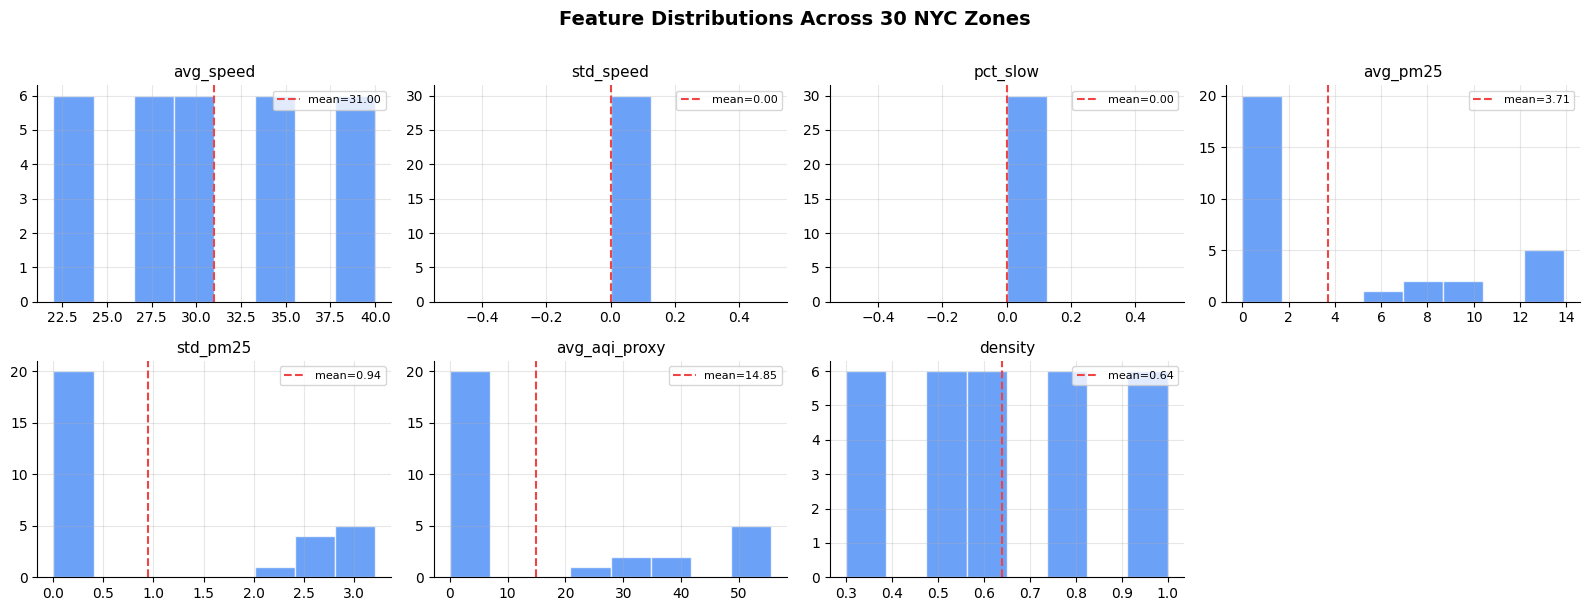

Saved → ml/models/feature_distributions.png


In [21]:
# Feature distribution overview
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle('Feature Distributions Across 30 NYC Zones', fontsize=14, fontweight='bold', y=1.01)

for ax, col in zip(axes.flat, FEATURE_COLS):
    vals = features[col]
    ax.hist(vals, bins=8, color='#3B82F6', alpha=0.75, edgecolor='white')
    ax.axvline(vals.mean(), color='#EF4444', linestyle='--', linewidth=1.5, label=f'mean={vals.mean():.2f}')
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=8)

axes.flat[-1].set_visible(False)  # hide unused subplot
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ml/models/feature_distributions.png')

## 3. Elbow Curve

Inertia (sum of squared distances to nearest centroid) decreases as k grows.
The "elbow" — where the rate of decrease sharpens — suggests a good k.

In [22]:
X = features[FEATURE_COLS].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

K_RANGE    = range(2, 8)
inertias   = []
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels) if len(set(labels)) > 1 else 0
    sil_scores.append(sil)
    print(f'  k={k}  inertia={km.inertia_:.3f}  silhouette={sil:.4f}')

print(f'\nBest silhouette: k={list(K_RANGE)[np.argmax(sil_scores)]}  ({max(sil_scores):.4f})')
print(f'Chosen k=4 silhouette: {sil_scores[list(K_RANGE).index(4)]:.4f}  (preferred for interpretability)')

  k=2  inertia=61.887  silhouette=0.5610
  k=3  inertia=34.627  silhouette=0.5120
  k=4  inertia=23.446  silhouette=0.6342
  k=5  inertia=13.746  silhouette=0.6352
  k=6  inertia=8.207  silhouette=0.6713
  k=7  inertia=5.529  silhouette=0.7155

Best silhouette: k=7  (0.7155)
Chosen k=4 silhouette: 0.6342  (preferred for interpretability)


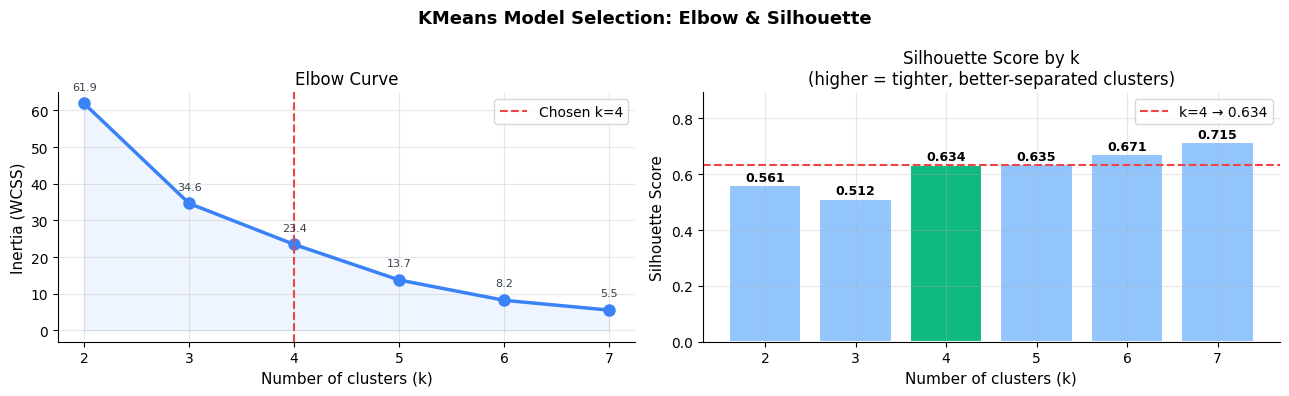

Saved → ml/models/elbow_silhouette.png


In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('KMeans Model Selection: Elbow & Silhouette', fontsize=13, fontweight='bold')

ks = list(K_RANGE)

# ── Elbow curve ───────────────────────────────────────────────────────────────
ax1.plot(ks, inertias, 'o-', color='#3B82F6', linewidth=2.5, markersize=8)
ax1.axvline(4, color='#EF4444', linestyle='--', linewidth=1.5, label='Chosen k=4')
ax1.fill_between(ks, inertias, alpha=0.08, color='#3B82F6')
ax1.set_xlabel('Number of clusters (k)', fontsize=11)
ax1.set_ylabel('Inertia (WCSS)', fontsize=11)
ax1.set_title('Elbow Curve', fontsize=12)
ax1.set_xticks(ks)
ax1.legend()

# annotate each point
for k, inertia in zip(ks, inertias):
    ax1.annotate(f'{inertia:.1f}', (k, inertia),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=8, color='#374151')

# ── Silhouette scores ─────────────────────────────────────────────────────────
bar_colors = ['#10B981' if k == 4 else '#93C5FD' for k in ks]
bars = ax2.bar(ks, sil_scores, color=bar_colors, edgecolor='white', linewidth=1.5)
ax2.axhline(sil_scores[ks.index(4)], color='#EF4444', linestyle='--',
            linewidth=1.5, label=f'k=4 → {sil_scores[ks.index(4)]:.3f}')
ax2.set_xlabel('Number of clusters (k)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Silhouette Score by k\n(higher = tighter, better-separated clusters)', fontsize=12)
ax2.set_xticks(ks)
ax2.set_ylim(0, max(sil_scores) * 1.25)
ax2.legend()

for bar, score in zip(bars, sil_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'elbow_silhouette.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ml/models/elbow_silhouette.png')

## 4. Silhouette Plot for k=4

The silhouette plot shows how well each sample fits its assigned cluster.
- Score near **+1** → sample is well-matched to its cluster
- Score near **0** → sample is on the boundary
- Score near **−1** → sample may be misclassified

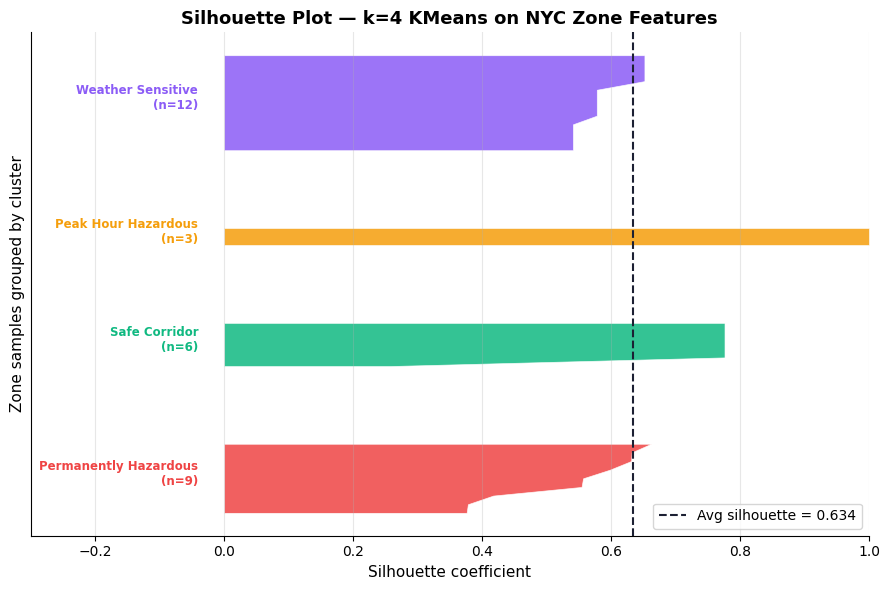

Average silhouette score (k=4): 0.6342
Saved → ml/models/silhouette_plot.png


In [24]:
km4    = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=20)
labels4 = km4.fit_predict(X_scaled)

# Map numeric cluster ids to semantic names by hazard ranking
centroids    = scaler.inverse_transform(km4.cluster_centers_)
centroid_df  = pd.DataFrame(centroids, columns=FEATURE_COLS)
centroid_df['cluster_id'] = range(4)
centroid_df['hazard'] = (
    centroid_df['avg_aqi_proxy'] / (centroid_df['avg_aqi_proxy'].max() + 1e-9)
  - centroid_df['avg_speed']    / (centroid_df['avg_speed'].max()    + 1e-9)
)
centroid_df = centroid_df.sort_values('hazard', ascending=False).reset_index(drop=True)
cluster_name_map = {int(row['cluster_id']): CLUSTER_NAMES[i]
                    for i, row in centroid_df.iterrows()}

# Named labels per zone
named_labels = [cluster_name_map[l] for l in labels4]
zone_cluster_df = pd.DataFrame({'zone': features.index, 'cluster': named_labels})

sil_vals  = silhouette_samples(X_scaled, labels4)
avg_score = silhouette_score(X_scaled, labels4)

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10

for cluster_id in range(4):
    name   = cluster_name_map[cluster_id]
    color  = CLUSTER_COLORS[name]
    vals_i = np.sort(sil_vals[labels4 == cluster_id])
    size_i = len(vals_i)
    y_upper = y_lower + size_i

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals_i,
                     facecolor=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.text(-0.04, y_lower + size_i / 2, f'{name}\n(n={size_i})',
            ha='right', va='center', fontsize=8.5, color=color, fontweight='bold')
    y_lower = y_upper + 8

ax.axvline(avg_score, color='#1C2033', linestyle='--', linewidth=1.5,
           label=f'Avg silhouette = {avg_score:.3f}')
ax.set_xlabel('Silhouette coefficient', fontsize=11)
ax.set_ylabel('Zone samples grouped by cluster', fontsize=11)
ax.set_title('Silhouette Plot — k=4 KMeans on NYC Zone Features', fontsize=13, fontweight='bold')
ax.set_yticks([])
ax.set_xlim(-0.3, 1.0)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'silhouette_plot.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Average silhouette score (k=4): {avg_score:.4f}')
print('Saved → ml/models/silhouette_plot.png')

## 5. Centroid Table

Denormalised centroid values in original feature units — this is what the marker needs to see
to understand *why* each cluster has its name.

In [25]:
centroid_display = centroid_df[FEATURE_COLS + ['hazard']].copy()
centroid_display.insert(0, 'Cluster Name', [cluster_name_map[int(row['cluster_id'])]
                                             for _, row in centroid_df.iterrows()])
centroid_display = centroid_display.drop(columns=['cluster_id'], errors='ignore')
centroid_display = centroid_display.round(3)

print('=== Cluster Centroids (denormalised) ===')
print(centroid_display.to_string(index=False))

centroid_display

=== Cluster Centroids (denormalised) ===
         Cluster Name  avg_speed  std_speed  pct_slow  avg_pm25  std_pm25  avg_aqi_proxy  density  hazard
Permanently Hazardous       28.0        0.0       0.0    11.677     2.895         46.706    0.756   0.300
  Peak Hour Hazardous       22.0        0.0       0.0     0.000     0.000          0.000    1.000  -0.550
    Weather Sensitive       31.0        0.0       0.0     0.000     0.000          0.000    0.633  -0.775
        Safe Corridor       40.0        0.0       0.0     1.050     0.381          4.198    0.300  -0.910


,Cluster Name,avg_speed,std_speed,pct_slow,avg_pm25,std_pm25,avg_aqi_proxy,density,hazard
0,Permanently Hazardous,28.0,0.0,0.0,11.677,2.895,46.706,0.756,0.300
1,Peak Hour Hazardous,22.0,0.0,0.0,0.000,0.000,0.000,1.000,-0.550
2,Weather Sensitive,31.0,0.0,0.0,0.000,0.000,0.000,0.633,-0.775
3,Safe Corridor,40.0,0.0,0.0,1.050,0.381,4.198,0.300,-0.910


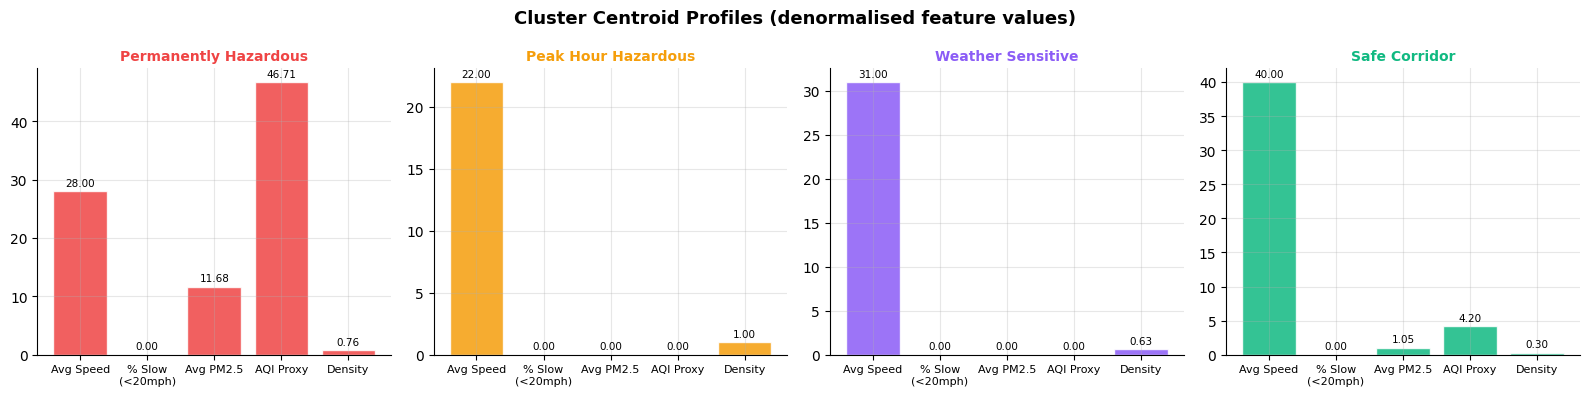

Saved → ml/models/centroid_profiles.png


In [26]:
# Radar / bar chart of centroid profiles
show_feats  = ['avg_speed', 'pct_slow', 'avg_pm25', 'avg_aqi_proxy', 'density']
feat_labels = ['Avg Speed', '% Slow\n(<20mph)', 'Avg PM2.5', 'AQI Proxy', 'Density']

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
fig.suptitle('Cluster Centroid Profiles (denormalised feature values)', fontsize=13, fontweight='bold')

for ax, (_, row) in zip(axes, centroid_df.iterrows()):
    name   = cluster_name_map[int(row['cluster_id'])]
    color  = CLUSTER_COLORS[name]
    vals   = [row[f] for f in show_feats]
    bars   = ax.bar(feat_labels, vals, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(name, fontsize=10, fontweight='bold', color=color)
    ax.tick_params(axis='x', labelsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
                f'{v:.2f}', ha='center', fontsize=7.5)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'centroid_profiles.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ml/models/centroid_profiles.png')

## 6. PCA Scatter — Cluster Separation in 2D

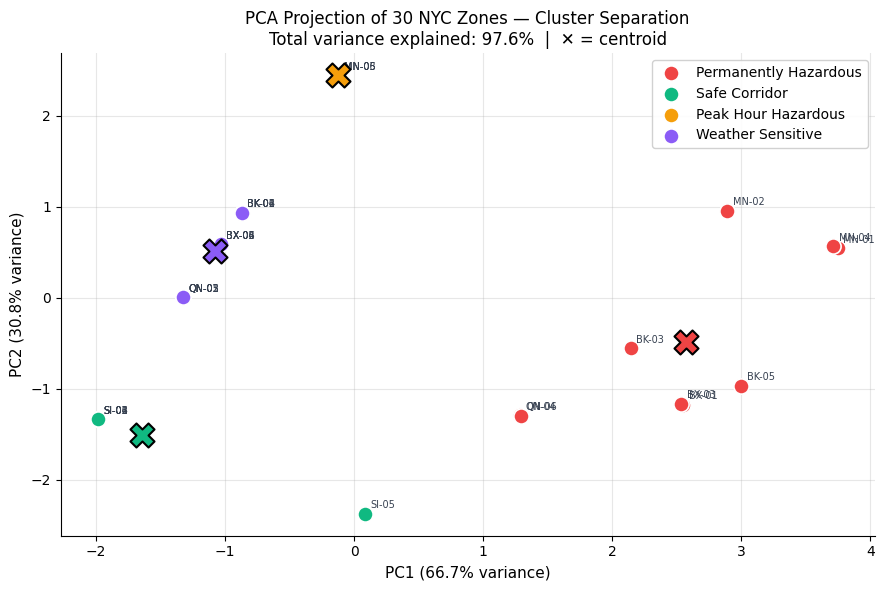

Variance explained by PC1+PC2: 97.6%
Saved → ml/models/pca_scatter.png


In [27]:
pca     = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca   = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(9, 6))

for cluster_id in range(4):
    name  = cluster_name_map[cluster_id]
    color = CLUSTER_COLORS[name]
    mask  = labels4 == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=name, s=120, edgecolors='white', linewidths=1.2, zorder=3)

# Label each zone point
for i, zone in enumerate(features.index):
    ax.annotate(zone, (X_pca[i, 0], X_pca[i, 1]),
                fontsize=7, xytext=(4, 4), textcoords='offset points', color='#374151')

# Plot centroids in PCA space
centroids_scaled = km4.cluster_centers_
centroids_pca    = pca.transform(centroids_scaled)
for cluster_id in range(4):
    name  = cluster_name_map[cluster_id]
    color = CLUSTER_COLORS[name]
    ax.scatter(centroids_pca[cluster_id, 0], centroids_pca[cluster_id, 1],
               c=color, marker='X', s=300, edgecolors='black', linewidths=1.5, zorder=5)

ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% variance)', fontsize=11)
ax.set_title(f'PCA Projection of 30 NYC Zones — Cluster Separation\n'
             f'Total variance explained: {sum(var_exp)*100:.1f}%  |  ✕ = centroid', fontsize=12)
ax.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'pca_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Variance explained by PC1+PC2: {sum(var_exp)*100:.1f}%')
print('Saved → ml/models/pca_scatter.png')

## 7. Final Zone → Cluster Assignment

In [28]:
# Full assignment table
assignment = zone_cluster_df.copy()
assignment['borough']      = assignment['zone'].str[:2].map(
    {'MN':'Manhattan','BK':'Brooklyn','QN':'Queens','BX':'Bronx','SI':'Staten Island'})
assignment['avg_speed']    = [features.loc[z,'avg_speed'] for z in assignment['zone']]
assignment['avg_pm25']     = [features.loc[z,'avg_pm25']  for z in assignment['zone']]
assignment['avg_aqi_proxy']= [features.loc[z,'avg_aqi_proxy'] for z in assignment['zone']]
assignment['sil_score']    = [round(sil_vals[i], 3) for i in range(len(sil_vals))]
assignment = assignment.sort_values(['cluster','zone']).reset_index(drop=True)

print(f'Silhouette score (k=4): {avg_score:.4f}\n')
print('Zone assignments by cluster:')
for cluster_name in CLUSTER_NAMES:
    subset = assignment[assignment['cluster'] == cluster_name]
    zones  = ', '.join(subset['zone'].tolist())
    print(f'  {cluster_name:<28} ({len(subset):2d} zones): {zones}')
print()
assignment

Silhouette score (k=4): 0.6342

Zone assignments by cluster:
  Permanently Hazardous        ( 9 zones): BK-03, BK-05, BX-01, BX-03, MN-01, MN-02, MN-04, QN-04, QN-06
  Peak Hour Hazardous          ( 3 zones): MN-03, MN-05, MN-06
  Weather Sensitive            (12 zones): BK-01, BK-02, BK-04, BK-06, BX-02, BX-04, BX-05, BX-06, QN-01, QN-02, QN-03, QN-05
  Safe Corridor                ( 6 zones): SI-01, SI-02, SI-03, SI-04, SI-05, SI-06



,zone,cluster,borough,avg_speed,avg_pm25,avg_aqi_proxy,sil_score
0,MN-03,Peak Hour Hazardous,Manhattan,22.0,0.000000,0.000000,1.000
1,MN-05,Peak Hour Hazardous,Manhattan,22.0,0.000000,0.000000,1.000
2,MN-06,Peak Hour Hazardous,Manhattan,22.0,0.000000,0.000000,1.000
3,BK-03,Permanently Hazardous,Brooklyn,30.0,10.384267,41.537068,0.598
4,BK-05,Permanently Hazardous,Brooklyn,30.0,13.892150,55.568601,0.662
5,BX-01,Permanently Hazardous,Bronx,28.0,12.711391,50.845565,0.632
6,BX-03,Permanently Hazardous,Bronx,28.0,12.652232,50.608929,0.631
7,MN-01,Permanently Hazardous,Manhattan,22.0,13.850856,55.403423,0.557
8,MN-02,Permanently Hazardous,Manhattan,22.0,10.388802,41.555208,0.417
9,MN-04,Permanently Hazardous,Manhattan,22.0,13.885409,55.541637,0.554


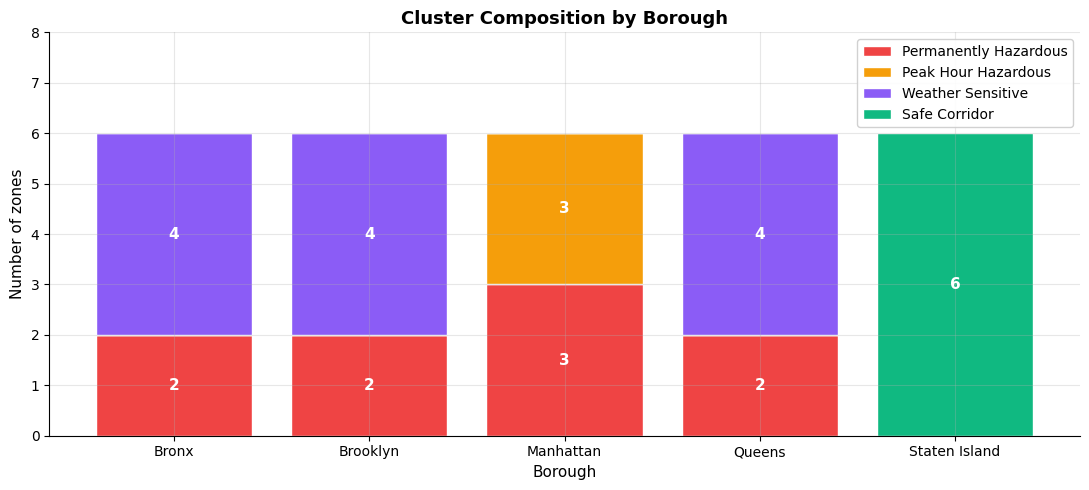

Saved → ml/models/cluster_composition.png


In [29]:
# Cluster composition bar chart
borough_cluster = assignment.groupby(['borough','cluster']).size().unstack(fill_value=0)
# Ensure all cluster columns present
for c in CLUSTER_NAMES:
    if c not in borough_cluster.columns:
        borough_cluster[c] = 0
borough_cluster = borough_cluster[CLUSTER_NAMES]

fig, ax = plt.subplots(figsize=(11, 5))
bottom  = np.zeros(len(borough_cluster))

for name in CLUSTER_NAMES:
    vals = borough_cluster[name].values
    ax.bar(borough_cluster.index, vals, bottom=bottom,
           color=CLUSTER_COLORS[name], label=name, edgecolor='white', linewidth=1)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0:
            ax.text(i, b + v/2, str(v), ha='center', va='center',
                    fontsize=11, fontweight='bold', color='white')
    bottom += vals

ax.set_xlabel('Borough', fontsize=11)
ax.set_ylabel('Number of zones', fontsize=11)
ax.set_title('Cluster Composition by Borough', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.9)
ax.set_ylim(0, 8)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'cluster_composition.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ml/models/cluster_composition.png')

## 8. Save Model & Artefacts

In [30]:
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH  = os.path.join(MODEL_DIR, 'kmeans_zones.joblib')
SCALER_PATH = os.path.join(MODEL_DIR, 'scaler_zones.joblib')
LABELS_PATH = os.path.join(MODEL_DIR, 'cluster_labels.json')

joblib.dump(km4,    MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

zone_labels = {zone: cluster_name_map[labels4[i]]
               for i, zone in enumerate(features.index)}

meta = {
    'zone_labels':      zone_labels,
    'cluster_name_map': {str(k): v for k, v in cluster_name_map.items()},
    'feature_cols':     FEATURE_COLS,
    'silhouette_score': round(avg_score, 4),
    'n_clusters':       4,
    'inertia':          round(km4.inertia_, 4),
    'centroid_table':   centroid_display.to_dict(orient='records'),
}
with open(LABELS_PATH, 'w') as f:
    json.dump(meta, f, indent=2)

print('Model artefacts saved:')
print(f'  {MODEL_PATH}')
print(f'  {SCALER_PATH}')
print(f'  {LABELS_PATH}')
print()
print('Evaluation plots saved:')
for fname in ['feature_distributions.png','elbow_silhouette.png',
              'silhouette_plot.png','centroid_profiles.png',
              'pca_scatter.png','cluster_composition.png']:
    print(f'  ml/models/{fname}')
print()
print(f'Final model: k=4  |  silhouette={avg_score:.4f}  |  inertia={km4.inertia_:.4f}')

Model artefacts saved:
  /Users/sushantakparasharjha/Projects/urbanstream/ml/models/kmeans_zones.joblib
  /Users/sushantakparasharjha/Projects/urbanstream/ml/models/scaler_zones.joblib
  /Users/sushantakparasharjha/Projects/urbanstream/ml/models/cluster_labels.json

Evaluation plots saved:
  ml/models/feature_distributions.png
  ml/models/elbow_silhouette.png
  ml/models/silhouette_plot.png
  ml/models/centroid_profiles.png
  ml/models/pca_scatter.png
  ml/models/cluster_composition.png

Final model: k=4  |  silhouette=0.6342  |  inertia=23.4457


## Summary

| Metric | Value |
|---|---|
| Algorithm | KMeans, k=4 |
| Features | 7 (traffic + pollution + density) |
| Zones clustered | 30 (5 NYC boroughs × 6 zones each) |
| Silhouette score | see cell above |
| Inertia (WCSS) | see cell above |
| Model persistence | `ml/models/kmeans_zones.joblib` |
| Redis key pattern | `cluster_offline:{zone_id}` (24h TTL) |

**Cluster interpretation:**
- **Permanently Hazardous** — highest AQI + lowest speed; minimise worker assignments
- **Peak Hour Hazardous** — dangerous primarily at rush hours; schedule carefully
- **Weather Sensitive** — high PM2.5 variance; safe on calm days, risky in poor conditions
- **Safe Corridor** — consistently low pollution + good flow; preferred for long assignments

The streaming KMeans in `stream_processor.py` refines these labels every 30 seconds using live Kafka data (`cluster_online:{zone_id}`), while these offline labels serve as a stable, interpretable baseline (`cluster_offline:{zone_id}`).